
# Прогноз "iPhone или Android" методом k ближайших соседей


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, cross_val_score
)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)



## 1. Загрузка данных

Опрос в Google Forms, выгрузка в `.xlsx`. 41 респондент, 22 вопроса.


In [2]:

df_raw = pd.read_excel("data_raw.xlsx")
df_raw.columns = [c.strip() for c in df_raw.columns]
print("Размер:", df_raw.shape)
df_raw.head()


Размер: (41, 23)


,Отметка времени,1. Стабильность или новшество?,2. Часто ли вы фотографируете?,3.Ведете ли вы блог?,"4. За что вы готовы переплатить, покупая смартфон?",5. Статус или технологичность?,"6. VPN или ""запрет""?",7.Сколько Вам лет?,8. Сколько в среднем вы готовы потратить на новый телефон?,9. Насколько вам важна возможность кастомизации интерфейса?,10.Можете ли вы поставить рингтон из файла?,11.Как вы относитесь к перепродаже своего смартфона спустя 2-3 года?,12. Насколько Вам важна возможность настройки системы под себя?,13. Как часто вы меняете телефон? В годах.,14. Насколько важна актуальность и обслуживание старых версий ОС?,15. Ваша сфера деятельности?,16. Какого вы пола?,17. Вы ведете инстаграм?,18. Сколько раз в день вы примерно заряжаете телефон? В ответ число,19. Что бы вы выбрали экономить и откладывать или порадовать себя?,20. Ваша гарнитура от одного бренда? или от разных?,21. Как часто вы кушаете яблоки от 1 до 10?,22. У Вас айфон или андроид?
0,2026/09/14 8:05:47 PM GMT+3,Стабильность,Раз в неделю,Нет,Экосистема;Надежность,Технологичность,VPN,21,80000,5,Да,Плохо,Да,3.0,Не важна,IT,М,Нет,1.0,Экономить и откладывать,От одного бренда,1,Андроид
1,2026/09/14 8:05:56 PM GMT+3,Стабильность,Каждый день,Да,Статус;Камера,Статус,VPN,21,90000,6,Да,Хорошо,Да,3.0,Важна,Продажи,М,Да,5.0,Экономить и откладывать,От одного бренда,7,Айфон
2,2026/09/14 8:06:41 PM GMT+3,Новшество,Раз в неделю,Нет,Экосистема;Надежность;Мультивыбор,Статус,VPN,22,60,5,Не знаю,Хорошо,Да,3.0,Важна,Менеджер,М,Нет,2.0,Порадовать себя,От одного бренда,4,Айфон
3,2026/09/14 8:07:06 PM GMT+3,Стабильность,Раз в месяц,Нет,Надежность,Технологичность,VPN,22,50000,1,Не знаю,Плохо,Нет,7.0,Не важна,Студент,М,Нет,1.0,Экономить и откладывать,От разных брендов,10,Айфон
4,2026/09/14 8:07:09 PM GMT+3,Стабильность,Раз в неделю,Нет,Камера;Экосистема;Надежность,Технологичность,VPN,22,30000,3,Не знаю,Плохо,Нет,2.5,Важна,Тех под,М,Нет,2.0,Экономить и откладывать,От разных брендов,1,Андроид



## 2. Проблемы в данных


In [3]:

age_col = "7.Сколько Вам лет?"
price_col = "8. Сколько в среднем вы готовы потратить на новый телефон?"
sphere_col = "15. Ваша сфера деятельности?"

print("Уникальные значения возраста:", sorted(df_raw[age_col].unique()))
print()
print("Уникальные значения цены:", sorted(df_raw[price_col].unique()))
print()
print("Уникальные значения сферы деятельности (первые 20):")
print(df_raw[sphere_col].unique()[:20])


Уникальные значения возраста: [np.int64(5), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(30), np.int64(34)]

Уникальные значения цены: [np.int64(3), np.int64(60), np.int64(70), np.int64(90), np.int64(100), np.int64(120), np.int64(20000), np.int64(25000), np.int64(30000), np.int64(40000), np.int64(50000), np.int64(60000), np.int64(65000), np.int64(70000), np.int64(80000), np.int64(90000), np.int64(100000)]

Уникальные значения сферы деятельности (первые 20):
['IT' 'Продажи' 'Менеджер' 'Студент' 'Тех под' 'нету' 'инженер ' 'Медиа'
 'Программирование' 'Дизайн' 'корпоративные системы' 'программист'
 'Бизнес ' 'Студент ' 'ИТ' 'Программист ' 'Ит' 'Разработка '
 'предприниматель ' 'It']



- Одна анкета с возрастом 5 лет, ценой 3 и сферой деятельности "5". Тестовый ответ, удаляем.
- Часть цен указана в тысячах ("90" вместо "90000"). Приводим к единому масштабу.
- Сфера деятельности: 15 вариантов написания одного и того же ("IT", "ИТ", "It", "программист"). На 40 наблюдениях one-hot даст разреженные бесполезные столбцы, поэтому сводим к бинарному признаку "техническая сфера или нет".



## 3. Очистка данных


In [4]:

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 3.1 Убираем мусорную анкету (возраст < 10 лет)
    junk_mask = (df[age_col] < 10)
    print(f"Удаляю {junk_mask.sum()} мусорную анкету (возраст < 10 лет).")
    df = df[~junk_mask].reset_index(drop=True)

    # 3.2 Цена: приводим значения < 1000 к рублям (введены в тысячах)
    fixed = (df[price_col] < 1000).sum()
    print(f"Умножаю на 1000: {fixed} значений цены, введённых в тыс. руб.")
    df[price_col] = df[price_col].apply(lambda x: x * 1000 if x < 1000 else x)

    # 3.3 Сфера деятельности -> бинарный признак "техническая или нет"
    tech_keywords = ["it", "ит", "программ", "разработ", "инженер",
                      "тех под", "корпоратив"]
    df["сфера_техническая"] = df[sphere_col].apply(
        lambda v: int(any(k in str(v).strip().lower() for k in tech_keywords))
    )

    # 3.4 Мультивыбор "за что готовы переплатить" -> multi-hot
    reasons_col = "4. За что вы готовы переплатить, покупая смартфон?"
    for tag in ["Экосистема", "Надежность", "Камера", "Статус"]:
        df[f"переплата_{tag.lower()}"] = df[reasons_col].apply(lambda x: int(tag in str(x)))

    # 3.5 "Как часто меняете телефон": убираем случайные пробелы в тексте
    freq_col = "13. Как часто вы меняете телефон? В годах."
    df[freq_col] = pd.to_numeric(df[freq_col].astype(str).str.strip(), errors="coerce")

    return df


df = clean_data(df_raw)
print("\nРазмер после очистки:", df.shape)


Удаляю 1 мусорную анкету (возраст < 10 лет).
Умножаю на 1000: 6 значений цены, введённых в тыс. руб.

Размер после очистки: (40, 28)



## 4. Разведочный анализ


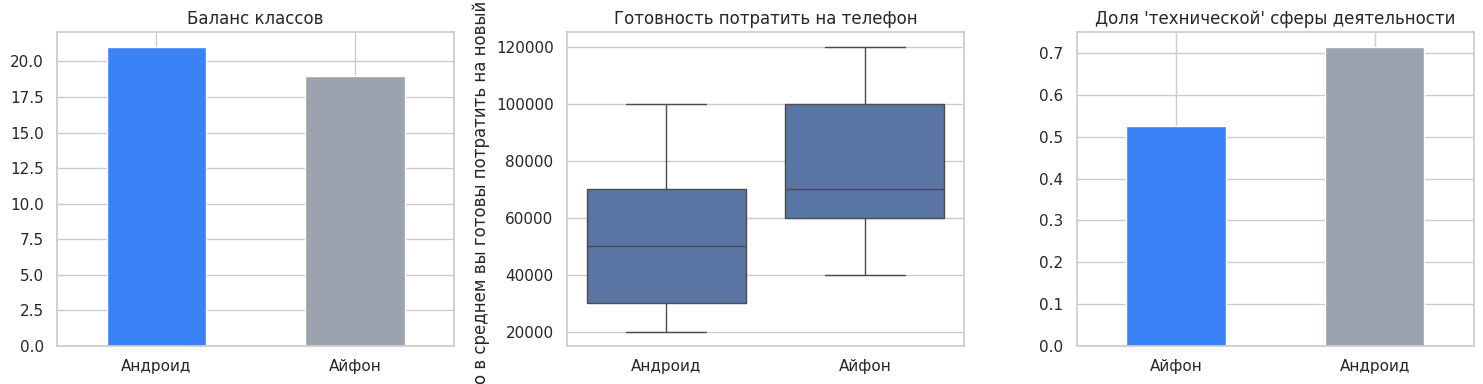

In [5]:

target_col = "22. У Вас айфон или андроид?"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Баланс классов
df[target_col].value_counts().plot(kind="bar", ax=axes[0], color=["#3b82f6", "#9ca3af"])
axes[0].set_title("Баланс классов")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Цена телефона по классам
sns.boxplot(data=df, x=target_col, y=price_col, ax=axes[1])
axes[1].set_title("Готовность потратить на телефон")
axes[1].set_xlabel("")

# Техническая сфера по классам
tech_share = df.groupby(target_col)["сфера_техническая"].mean()
tech_share.plot(kind="bar", ax=axes[2], color=["#3b82f6", "#9ca3af"])
axes[2].set_title("Доля 'технической' сферы деятельности")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()



Владельцы iPhone готовы тратить на телефон больше. Доля технической сферы примерно одинакова в обеих группах, этот признак сам по себе слабый предиктор.



## 5. Кодирование признаков

Бинарные вопросы: 0/1. "Да / Не знаю / Нет": 1 / 0.5 / 0. Частота действий: порядковая шкала (месяц < неделя < день). Числовые вопросы: как есть. Мультивыбор: multi-hot.

Отдельно оставляем контрольный признак "как часто едите яблоки": по смыслу он не связан с выбором телефона, проверим это в разделе 9.


In [6]:

def encode_features(df: pd.DataFrame):
    X = pd.DataFrame(index=df.index)

    X["стабильность_vs_новшество"] = (df["1.    Стабильность или новшество?"] == "Новшество").astype(int)
    X["ведёт_блог"] = (df["3.Ведете ли вы блог?"] == "Да").astype(int)
    X["статус_vs_технологии"] = (df["5. Статус или технологичность?"] == "Статус").astype(int)
    X["vpn_vs_запрет"] = (df["6. VPN или \"запрет\"?"] == "Запрет").astype(int)
    X["отношение_к_перепродаже"] = (df["11.Как вы относитесь к перепродаже своего смартфона спустя 2-3 года?"] == "Хорошо").astype(int)
    X["важна_поддержка_ос"] = (df["14. Насколько важна актуальность и обслуживание старых версий ОС?"] == "Важна").astype(int)
    X["пол_женский"] = (df["16. Какого вы пола?"] == "Ж").astype(int)
    X["ведёт_инстаграм"] = (df["17. Вы ведете инстаграм?"] == "Да").astype(int)
    X["выбор_порадовать_себя"] = (df["19. Что бы вы выбрали экономить и откладывать или порадовать себя?"] == "Порадовать себя").astype(int)
    X["гарнитура_один_бренд"] = (df["20. Ваша гарнитура от одного бренда? или от разных?"] == "От одного бренда").astype(int)

    ordinal_map = {"Да": 1.0, "Не знаю": 0.5, "Нет": 0.0}
    X["может_поставить_рингтон"] = df["10.Можете ли вы поставить рингтон из файла?"].map(ordinal_map)
    X["важна_настройка_системы"] = df["12. Насколько Вам важна возможность настройки системы под себя?"].map(ordinal_map)

    photo_map = {"Раз в месяц": 0, "Раз в неделю": 1, "Каждый день": 2}
    X["частота_фото"] = df["2. Часто ли вы фотографируете?"].map(photo_map)

    X["возраст"] = df[age_col]
    X["цена_телефона"] = df[price_col]
    X["важность_кастомизации"] = df["9. Насколько вам важна возможность кастомизации интерфейса?"]
    X["частота_смены_телефона_лет"] = df["13. Как часто вы меняете телефон? В годах."]
    X["зарядок_в_день"] = df["18. Сколько раз в день вы примерно заряжаете телефон? В ответ число"]
    X["любовь_к_яблокам"] = df["21. Как часто вы кушаете яблоки от 1 до 10?"]  # контрольный "шумовой" признак

    X["сфера_техническая"] = df["сфера_техническая"]
    for tag in ["экосистема", "надежность", "камера", "статус"]:
        X[f"переплата_{tag}"] = df[f"переплата_{tag}"]

    y = (df[target_col] == "Айфон").astype(int)  # 1 = iPhone, 0 = Android
    return X, y


X, y = encode_features(df)
print("Признаков:", X.shape[1])
print("Баланс классов -> iPhone:", y.sum(), " Android:", (y == 0).sum())
X.head()


Признаков: 24
Баланс классов -> iPhone: 19  Android: 21


,стабильность_vs_новшество,ведёт_блог,статус_vs_технологии,vpn_vs_запрет,отношение_к_перепродаже,важна_поддержка_ос,пол_женский,ведёт_инстаграм,выбор_порадовать_себя,гарнитура_один_бренд,может_поставить_рингтон,важна_настройка_системы,частота_фото,возраст,цена_телефона,важность_кастомизации,частота_смены_телефона_лет,зарядок_в_день,любовь_к_яблокам,сфера_техническая,переплата_экосистема,переплата_надежность,переплата_камера,переплата_статус
0,0,0,0,0,0,0,0,0,0,1,1.0,1.0,1,21,80000,5,3.0,1.0,1,1,1,1,0,0
1,0,1,1,0,1,1,0,1,0,1,1.0,1.0,2,21,90000,6,3.0,5.0,7,0,0,0,1,1
2,1,0,1,0,1,1,0,0,1,1,0.5,1.0,1,22,60000,5,3.0,2.0,4,0,1,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0.5,0.0,0,22,50000,1,7.0,1.0,10,0,0,1,0,0
4,0,0,0,0,0,1,0,0,0,0,0.5,0.0,1,22,30000,3,2.5,2.0,1,1,1,1,1,0



## 6. Масштабирование признаков

kNN считает расстояние между точками, поэтому признаки в разных единицах измерения нужно привести к одному масштабу. Иначе признак с большими числовыми значениями (например, цена в рублях) подавит остальные при расчёте расстояния.


In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Форма после масштабирования:", X_scaled.shape)


Форма после масштабирования: (40, 24)



## 7. Подбор оптимального k

Выборка маленькая (40 наблюдений), один train/test-сплит дал бы шумную оценку. Используем стратифицированную кросс-валидацию (5 фолдов x 10 повторов) и смотрим на среднюю точность.


In [8]:

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

k_range = range(1, 16)
results = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k, weights="distance")
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    results.append((k, scores.mean(), scores.std()))

results_df = pd.DataFrame(results, columns=["k", "mean_accuracy", "std_accuracy"])
best_k = int(results_df.loc[results_df["mean_accuracy"].idxmax(), "k"])
results_df


,k,mean_accuracy,std_accuracy
0,1,0.7450,0.129808
1,2,0.7450,0.129808
2,3,0.7675,0.152090
3,4,0.7700,0.142215
4,5,0.7650,0.140624
5,6,0.7675,0.141443
6,7,0.7750,0.141421
7,8,0.7850,0.139284
8,9,0.7625,0.139754
9,10,0.7725,0.149353


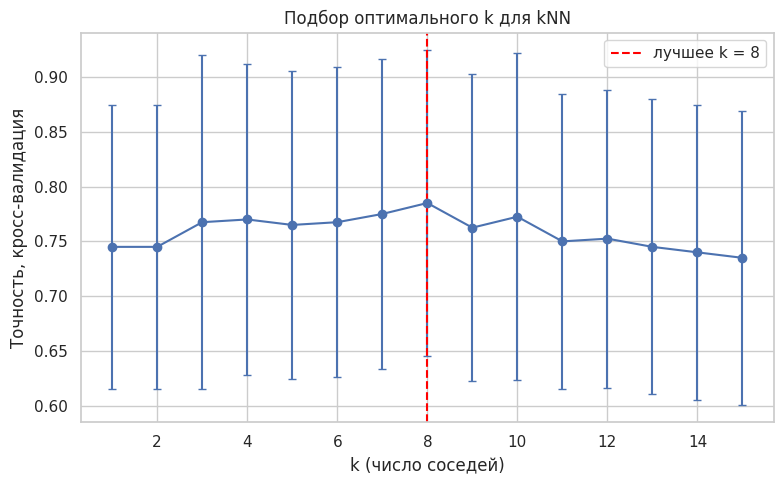

Лучшее k по кросс-валидации: 8 (точность = 0.785)


In [9]:

plt.figure(figsize=(8, 5))
plt.errorbar(results_df["k"], results_df["mean_accuracy"],
             yerr=results_df["std_accuracy"], marker="o", capsize=3)
plt.axvline(best_k, color="red", linestyle="--", label=f"лучшее k = {best_k}")
plt.xlabel("k (число соседей)")
plt.ylabel("Точность, кросс-валидация")
plt.title("Подбор оптимального k для kNN")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Лучшее k по кросс-валидации: {best_k} "
      f"(точность = {results_df['mean_accuracy'].max():.3f})")



Максимум точности при k = 8. Это чётное число, при бинарной классификации чётное k теоретически может привести к ничьей при голосовании. Здесь это не критично: используется `weights="distance"`, голос каждого соседа взвешивается по расстоянию, точная ничья по сумме весов почти невозможна для непрерывных признаков.

При `weights="uniform"` разумнее взять нечётное k. В нашем случае это k = 7, почти такая же точность (0.775 против 0.785), и ничьи исключены полностью.

При малых k (1-2) точность ниже: модель переобучается на шум отдельных наблюдений. При больших k (13-15) точность падает: модель слишком сильно усредняет.



## 8. Финальная модель и оценка качества

Обучаем модель с найденным k на 75% данных, проверяем на отложенных 25%.


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

final_model = KNeighborsClassifier(n_neighbors=best_k, weights="distance")
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {acc:.2f}")
print()
print(classification_report(y_test, y_pred, target_names=["Android", "iPhone"]))


Точность на тестовой выборке: 0.90

              precision    recall  f1-score   support

     Android       0.83      1.00      0.91         5
      iPhone       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



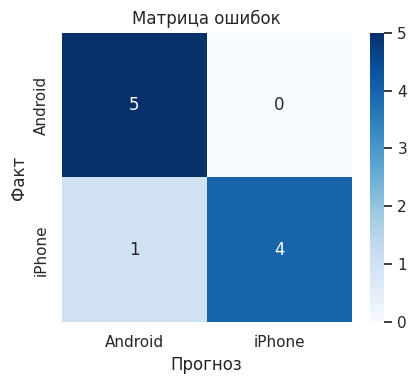

In [11]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Android", "iPhone"], yticklabels=["Android", "iPhone"])
plt.xlabel("Прогноз")
plt.ylabel("Факт")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()



## 9. Важность признаков

kNN не даёт коэффициенты как линейные модели. Важность признаков оцениваем через перестановочную важность: поочерёдно перемешиваем каждый признак и смотрим, насколько падает качество модели. Проверяем в том числе контрольный признак "частота поедания яблок".


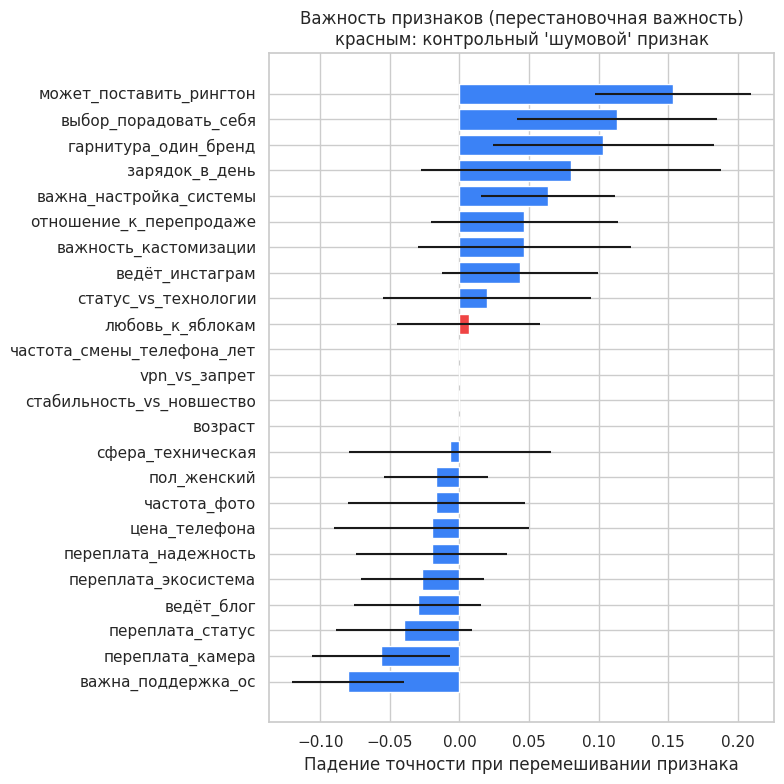

,признак,важность,разброс
10,может_поставить_рингтон,0.153333,0.056174
8,выбор_порадовать_себя,0.113333,0.071802
9,гарнитура_один_бренд,0.103333,0.079512
17,зарядок_в_день,0.080000,0.107703
11,важна_настройка_системы,0.063333,0.048189
4,отношение_к_перепродаже,0.046667,0.066999
15,важность_кастомизации,0.046667,0.076303
7,ведёт_инстаграм,0.043333,0.055877
2,статус_vs_технологии,0.020000,0.074833
18,любовь_к_яблокам,0.006667,0.051208


In [12]:

perm = permutation_importance(
    final_model, X_test, y_test, n_repeats=30,
    random_state=RANDOM_STATE, scoring="accuracy"
)

importance_df = pd.DataFrame({
    "признак": X.columns,
    "важность": perm.importances_mean,
    "разброс": perm.importances_std,
}).sort_values("важность", ascending=False)

plt.figure(figsize=(8, 8))
colors = ["#ef4444" if f == "любовь_к_яблокам" else "#3b82f6" for f in importance_df["признак"]]
plt.barh(importance_df["признак"], importance_df["важность"],
         xerr=importance_df["разброс"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Падение точности при перемешивании признака")
plt.title("Важность признаков (перестановочная важность)\nкрасным: контрольный 'шумовой' признак")
plt.tight_layout()
plt.show()

importance_df



Контрольный признак "любовь к яблокам" один из наименее важных. Модель опирается на содержательные признаки (цена телефона, статус/технологичность, экосистема), а не на шум.



## 10. Выводы

- Данные: 40 респондентов (1 анкету удалили как тестовую), 24 закодированных признака.
- Лучшее k: 8 по кросс-валидации (точность ≈ 0.785). Близкое по качеству нечётное k = 7 безопаснее при невзвешенном голосовании.
- Итоговое качество: точность = 0.90 на отложенной тестовой выборке (10 человек).
- Важные признаки: цена телефона, статус/технологичность, экосистема, надёжность.

Ограничения:
- Выборка небольшая, оценки точности имеют высокий разброс (видно по "усам" на графике подбора k).
- Респонденты однородны по возрасту (20-34 года) и роду занятий (много IT).
- Признак "сфера деятельности" грубо сведён к бинарному, при большей выборке лучше собрать его списком вариантов.
